# TxDOT Five-Column Bent Cap - Global STM Validation

This is an input-adjusted copy of the production notebook. The production notebook and analysis modules are unchanged. Loads, supports, and geometry are taken from Figure 4.10 of TxDOT Report 5-5253-01-1.


## Important status

- The included load factors are demonstration values, **not AREMA design combinations**.
- Enter project-specific combinations from the governing AREMA edition.
- Positive member force denotes tension; negative force denotes compression.
- AREMA 2025 Article 2.30.2b resistance factors, Article 2.42 nodal factors, and the supplied reinforcement provisions are implemented.
- Final three-dimensional bar positioning, drawings, foundation design, and project load generation are outside this two-dimensional analysis.
- Arbitrary polygonal cross-section and local ledge analysis are outside this notebook's scope.

In [1]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'stm_solver').exists() and (path / 'notebooks' / 'pier_cap_design.ipynb').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from stm_solver.design_checks import (
    apply_conservative_strut_policy, arema_2025_nodal_stress_factors, arema_2025_stm_resistance_factors, calculate_strut_width_profiles,
    REBAR_TABLE, calculate_standard_hook_development,
    calculate_tension_development_length,
    calculate_tie_end_anchorage_geometry, check_reinforcement_cage_congestion,
    check_strut, check_interior_nodal_zone_faces, classify_strut_shapes, design_orthogonal_crack_control_grid,
    check_provided_crack_control_grid, check_provided_tie_bar_layout,
    design_tie_bar_layout, extended_strut_tie_critical_section,
    check_subdivided_nodal_zone_faces, check_tie,
    construct_continuous_tie_nodal_zone,
    construct_single_strut_external_nodal_zone,
)
from stm_solver.ground_structure import (
    find_member_crossings, optimize_frame_boundary_load_cases,
    optimize_pier_cap_load_cases,
)
from stm_solver.pier_cap import (
    FoundationSupport, LoadCombination, LoadComponent, LoadPointForce,
    PierCapGeometry, PierCapLoadSet, PierCapModel,
)
from stm_solver.tables import (
    conservative_strut_design_records, crack_control_records,
    design_check_records, export_csv_tables, export_excel_tables, export_json_tables, ground_structure_records, multi_load_ground_structure_records, nodal_geometry_records, pier_cap_analysis_records,
    strut_shape_records, strut_width_records, tie_anchorage_records,
    reinforcement_cage_review_records,
    standard_hook_records, tension_development_records,
    tie_bar_layout_records,
    records_to_dataframes,
)
from stm_solver.reporting import (
    build_pier_cap_calculation_report, build_pier_cap_html_report,
    write_calculation_report, write_html_report,
)
from stm_solver.versioning import build_calculation_metadata

## 1. User inputs

Edit only this section for a new demonstration model. Keep all coordinates in inches and forces in kips. Load-point IDs must retain the same coordinates in every component in which they appear.

In [2]:
project = {
    'name': 'TxDOT 5-5253-01-1 Chapter 4 - Global STM Validation',
    'designer': 'Validation benchmark',
    'date': '09/24/2026',
    'revision': '0',
    'governing_standard': 'TxDOT Report 5-5253-01-1, Chapter 4',
    'units': {'length': 'in', 'force': 'kip', 'stress': 'ksi'},
}

# Figure 4.1: 85-ft constant-depth cap, 3.5 ft deep by 4.5 ft wide.
# Figure 4.11: chord centroids are 3.58 in from the top and bottom faces.
cap = {
    'length': 1020.0,
    'depth': 42.0,
    'width': 54.0,
    'top_tie_y': 38.42,
    'bottom_tie_y': 3.58,
}

# The worked design increases f'c from 3.6 ksi to 4.0 ksi after the nodal review.
materials = {'fc_ksi': 4.0, 'fy_ksi': 60.0}

detailing = {
    'clear_cover': 2.25,
    'maximum_aggregate_size': 0.75,
    'lightweight_concrete': False,
    'epoxy_coated_reinforcement': False,
    'minimum_longitudinal_bar_size': 11,
    'maximum_longitudinal_bar_size': 11,
    'allow_standard_hooks': True,
}

provided_reinforcement = {
    'top': {'bar_count': 7, 'bar_size': 11, 'layers': 1},
    'bottom': {'bar_count': 4, 'bar_size': 11, 'layers': 1},
    'crack_control': {
        'vertical': {'steel_area_per_spacing': 0.62, 'spacing': 4.9},
        'horizontal': {'steel_area_per_spacing': 0.31, 'spacing': 4.9},
    },
}

# The production design checks retain their verified AREMA profile. Published
# TxDOT force-flow values are compared independently on a same-basis statics
# basis; code-basis differences are identified in the validation report.
arema_phi = arema_2025_stm_resistance_factors()
code_profile = {
    'name': 'AREMA 2025 production checks; TxDOT global STM comparison',
    'phi_tie': arema_phi['reinforced_concrete_tension'],
    'phi_concrete': arema_phi['compression'],
    'resistance_factor_status': 'Production AREMA profile retained unchanged',
}

output_options = {
    'write_files': True,
    'directory': repo_root / 'validation' / 'txdot_five_column_bent' / 'v1.0.0' / 'output',
    'write_excel': False,
}

# Figure 4.10 column centerlines: 4.5-ft end cantilever and 19-ft spacing.
# One pin supplies horizontal stability; the remaining columns are vertical rollers.
piles = [
    {'id': 'C1', 'x': 54.0, 'y': 0.0, 'type': 'pin', 'face_width': 31.9, 'foundation_type': 'shaft'},
    {'id': 'C2', 'x': 282.0, 'y': 0.0, 'type': 'roller', 'face_width': 31.9, 'foundation_type': 'shaft'},
    {'id': 'C3', 'x': 510.0, 'y': 0.0, 'type': 'roller', 'face_width': 31.9, 'foundation_type': 'shaft'},
    {'id': 'C4', 'x': 738.0, 'y': 0.0, 'type': 'roller', 'face_width': 31.9, 'foundation_type': 'shaft'},
    {'id': 'C5', 'x': 966.0, 'y': 0.0, 'type': 'roller', 'face_width': 31.9, 'foundation_type': 'shaft'},
]

# Authoritative applied resultants from Figure 4.10. Coordinates accumulate the
# published panel dimensions from the left end of the 85-ft cap.
load_components = {'TXDOT_FIGURE_4_10': [
    {'id': 'A', 'x': 26.52, 'y': 42.0, 'Px': 0.0, 'Py': -228.4},
    {'id': 'B', 'x': 111.48, 'y': 42.0, 'Px': 0.0, 'Py': -126.1},
    {'id': 'C', 'x': 142.68, 'y': 42.0, 'Px': 0.0, 'Py': -124.0},
    {'id': 'D', 'x': 192.12, 'y': 42.0, 'Px': 0.0, 'Py': -127.0},
    {'id': 'F', 'x': 268.20, 'y': 42.0, 'Px': 0.0, 'Py': -250.4},
    {'id': 'G', 'x': 353.52, 'y': 42.0, 'Px': 0.0, 'Py': -126.1},
    {'id': 'H', 'x': 384.72, 'y': 42.0, 'Px': 0.0, 'Py': -130.2},
    {'id': 'I', 'x': 434.16, 'y': 42.0, 'Px': 0.0, 'Py': -127.0},
    {'id': 'K', 'x': 510.00, 'y': 42.0, 'Px': 0.0, 'Py': -263.4},
    {'id': 'M', 'x': 599.76, 'y': 42.0, 'Px': 0.0, 'Py': -331.0},
    {'id': 'O', 'x': 676.08, 'y': 42.0, 'Px': 0.0, 'Py': -124.5},
    {'id': 'P', 'x': 699.24, 'y': 42.0, 'Px': 0.0, 'Py': -233.3},
    {'id': 'Q', 'x': 756.72, 'y': 42.0, 'Px': 0.0, 'Py': -124.3},
    {'id': 'R', 'x': 795.96, 'y': 42.0, 'Px': 0.0, 'Py': -212.8},
    {'id': 'S', 'x': 837.36, 'y': 42.0, 'Px': 0.0, 'Py': -124.3},
    {'id': 'T', 'x': 892.68, 'y': 42.0, 'Px': 0.0, 'Py': -137.8},
    {'id': 'U', 'x': 918.00, 'y': 42.0, 'Px': 0.0, 'Py': -124.7},
    {'id': 'V', 'x': 993.96, 'y': 42.0, 'Px': 0.0, 'Py': -243.8},
]}

# Section 4.2.3: 16.2-in equivalent square for a single girder and 23.0 in for
# two combined girders. The wider faces below are identified by the bearing bars
# and combined resultants in Figure 4.10.
load_face_widths = {name: 16.2 for name in ('B','C','D','G','H','I','O','Q','R','S','T','U')}
load_face_widths.update({name: 23.0 for name in ('A','F','K','M','P','V')})

load_combinations = {'TXDOT_GLOBAL': {'TXDOT_FIGURE_4_10': 1.0}}
# Figure 4.10 dimensions are printed to 0.01 ft. Reconstructing them literally
# makes one generated candidate marginally less than 25 degrees, so this
# validation copy uses 24 degrees to avoid treating publication rounding as a
# geometry failure. This is not a production-default change.
generation = {'min_angle': 24.0, 'max_angle': 90.0}
analysis_mode = 'pier_cap'
frame_model = None


## Validation scope note

The scored global comparison is generated separately by `run_validation.py`. Column-support nodal submodels and checks that use their revised local strut angles are excluded from pass/fail scoring.


## 2. Validate and assemble load combinations

This gate stops the analysis for invalid geometry, unknown components, inconsistent load-point coordinates, or loads and piles outside the longitudinal cap envelope.

In [3]:
run_design_checks = analysis_mode == 'pier_cap'
if run_design_checks:
    geometry = PierCapGeometry(
        depth=cap['depth'], top_tie_y=cap['top_tie_y'],
        bottom_tie_y=cap['bottom_tie_y'], length=cap['length'], width=cap['width'],
    )
    supports = tuple(
        FoundationSupport(
            pile['id'], pile['x'], pile['y'], pile['face_width'],
            restraint=pile['type'], foundation_type=pile.get('foundation_type', 'pile'),
        )
        for pile in piles
    )
    components = tuple(
        LoadComponent(name, tuple(
            LoadPointForce(
                load['id'], load['x'], load['y'], load['Py'], px=load.get('Px', 0.0),
            )
            for load in loads
        ))
        for name, loads in load_components.items()
    )
    combinations = tuple(LoadCombination(name, factors) for name, factors in load_combinations.items())
    load_set = PierCapLoadSet(components, combinations, load_face_widths)
    load_set.validate_envelope(geometry)
    assembled_loads = load_set.assemble_all()
    models = {name: PierCapModel(geometry, loads, supports, metadata=project) for name, loads in assembled_loads.items()}
    combination_loads = {name: [load.to_solver_dict() for load in loads] for name, loads in assembled_loads.items()}
    piles = [support.to_solver_dict() for support in supports]
    print(f"Validated {len(supports)} supports, {len(components)} load components, and {len(models)} combinations.")
else:
    if frame_model is None:
        raise ValueError("frame_model is required when analysis_mode='frame_boundary'")
    frame_nodes = frame_model['top_nodes'] + frame_model['lower_nodes'] + frame_model['boundary_nodes']
    frame_node_lookup = {node['id']: node for node in frame_nodes}
    combination_loads = {
        name: [dict(load, id=load['node'], x=frame_node_lookup[load['node']]['x'], y=frame_node_lookup[load['node']]['y']) for load in loads]
        for name, loads in frame_model['load_cases'].items()
    }
    piles = [dict(node, type='fixed', face_width=0.0) for node in frame_model['boundary_nodes']]
    models = {}
    print(f"Validated {len(frame_model['boundary_nodes'])} frame-boundary nodes and {len(combination_loads)} load case(s).")
for name, loads in combination_loads.items():
    resultant = np.sum([[load.get('Px', 0.0), load.get('Py', 0.0)] for load in loads], axis=0)
    print(f"  {name:<30} Fx={resultant[0]:9.1f} kip  Fy={resultant[1]:9.1f} kip")


Validated 5 supports, 1 load components, and 1 combinations.
  TXDOT_GLOBAL                   Fx=      0.0 kip  Fy=  -3159.1 kip


## 3. Generate and solve one common STM ground structure

One candidate structure is generated from the common physical load/support locations. Candidates unused by every combination are pruned, every case is re-solved for equilibrium, and force reversals are reported explicitly.

In [4]:
if run_design_checks:
    common_analysis = optimize_pier_cap_load_cases(
        combination_loads, piles,
        top_tie_y=cap['top_tie_y'], bottom_tie_y=cap['bottom_tie_y'],
        min_angle=generation['min_angle'], max_angle=generation['max_angle'],
    )
else:
    common_analysis = optimize_frame_boundary_load_cases(
        frame_model['top_nodes'], frame_model['lower_nodes'], frame_model['boundary_nodes'],
        frame_model['load_cases'],
        boundary_member_targets=frame_model.get('boundary_member_targets'),
        target_relative_tolerance=frame_model.get('target_relative_tolerance', 0.0),
        min_angle=generation['min_angle'], max_angle=generation['max_angle'],
        force_tolerance=generation.get('force_tolerance', 1e-6),
    )
results = common_analysis.case_results

summary_records = []
for name, result in results.items():
    summary_records.append({
        'combination': name, 'candidate_count': result.candidate_count,
        'selected_count': len(result.member_forces),
        'equilibrium_residual_kip': result.equilibrium_residual,
    })
    assert result.equilibrium_residual < 1e-7
result_tables = {name: records_to_dataframes(ground_structure_records(result)) for name, result in results.items()}
summary_table = records_to_dataframes({'summary': summary_records})['summary']
common_tables = records_to_dataframes(multi_load_ground_structure_records(common_analysis))
display(summary_table)
print(f'Common candidates: {common_analysis.initial_candidate_count} generated, {len(common_analysis.members)} retained after {common_analysis.pruning_iterations} pruning iteration(s).')
if common_analysis.force_reversals:
    display(common_tables['force_reversals'])
else:
    print('Force-reversal check: PASS - no common member changes between tension and compression.')


,combination,candidate_count,selected_count,equilibrium_residual_kip
0,TXDOT_GLOBAL,87,87,2.273737e-13


Common candidates: 137 generated, 87 retained after 1 pruning iteration(s).
Force-reversal check: PASS - no common member changes between tension and compression.


In [5]:
crossing_failures = {}
for name, result in results.items():
    crossings = find_member_crossings(
        result.truss_model.nodes, result.truss_model.members,
    )
    if crossings:
        crossing_failures[name] = crossings
if crossing_failures:
    details = '; '.join(
        f'{name}: member-index pairs {pairs}'
        for name, pairs in crossing_failures.items()
    )
    raise RuntimeError(
        'Topology review failed: unintended non-nodal member crossings were found. '
        + details
    )
print('Crossing check: PASS - no non-nodal selected-member intersections.')

Crossing check: PASS - no non-nodal selected-member intersections.


In [6]:
if run_design_checks:
    print(f"{'combination':<30} {'support':<10} {'Rx (kip)':>12} {'Ry (kip)':>12}")
    print('-' * 68)
    inactive_supports = []
    for name, result in results.items():
        for pile_index, pile in enumerate(piles):
            node = result.truss_model.support_node_ids[pile_index]
            rx = result.reactions.get(2 * node, 0.0)
            ry = result.reactions.get(2 * node + 1, 0.0)
            print(f"{name:<30} {pile['id']:<10} {rx:12.1f} {ry:12.1f}")
            if abs(rx) < 1e-6 and abs(ry) < 1e-6:
                inactive_supports.append((name, pile['id']))
else:
    print(f"{'combination':<30} {'boundary':<10} {'Rx (kip)':>12} {'Ry (kip)':>12}")
    print('-' * 68)
    offset = len(frame_model['top_nodes']) + len(frame_model['lower_nodes'])
    for name, result in results.items():
        for boundary_index, boundary in enumerate(frame_model['boundary_nodes']):
            node = offset + boundary_index
            print(f"{name:<30} {boundary['id']:<10} {result.reactions.get(2*node, 0.0):12.1f} {result.reactions.get(2*node+1, 0.0):12.1f}")


combination                    support        Rx (kip)     Ry (kip)
--------------------------------------------------------------------
TXDOT_GLOBAL                   C1                 -0.0        399.7
TXDOT_GLOBAL                   C2                  0.0        748.1
TXDOT_GLOBAL                   C3                  0.0        354.8
TXDOT_GLOBAL                   C4                  0.0       1346.6
TXDOT_GLOBAL                   C5                  0.0        309.9


## 4. Topology and force review

Line width is proportional to force magnitude. Red members are ties; blue members are struts. This plot is a required engineering review gate—not merely presentation output.

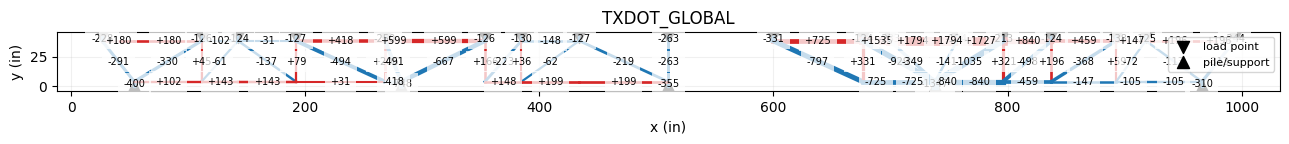

In [7]:
fig, axes = plt.subplots(len(results), 1, figsize=(13, 4.2 * len(results)), squeeze=False)
for ax, (name, result) in zip(axes[:, 0], results.items()):
    truss = result.truss_model
    scale = max(abs(result.member_forces))
    for (i, j), kind, force in zip(truss.members, truss.member_types, result.member_forces):
        color = '#d62728' if kind == 'tie' else '#1f77b4'
        width = 1.4 + 5.0 * abs(force) / scale
        ax.plot(truss.nodes[[i, j], 0], truss.nodes[[i, j], 1], color=color, lw=width)
        midpoint = (truss.nodes[i] + truss.nodes[j]) / 2
        ax.text(*midpoint, f'{force:+.0f}', fontsize=7, ha='center', va='center',
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'})
    loads = combination_loads[name]
    ax.scatter([load['x'] for load in loads], [load['y'] for load in loads],
               marker='v', s=75, color='black', label='load point')
    ax.scatter([pile['x'] for pile in piles], [pile['y'] for pile in piles],
               marker='^', s=75, color='black', label=('pile/support' if run_design_checks else 'frame boundary'))
    node_min = np.min(truss.nodes, axis=0)
    node_max = np.max(truss.nodes, axis=0)
    node_span = np.maximum(node_max - node_min, 1.0)
    length_unit = project['units']['length']
    ax.set(title=name, xlabel=f'x ({length_unit})', ylabel=f'y ({length_unit})', aspect='equal',
           xlim=(node_min[0] - 0.04 * node_span[0], node_max[0] + 0.04 * node_span[0]),
           ylim=(node_min[1] - 0.10 * node_span[1], node_max[1] + 0.10 * node_span[1]))
    ax.grid(alpha=0.18)
    ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

In [8]:
def member_signature(result, member):
    i, j = member
    points = [
        tuple(float(value) for value in np.round(result.truss_model.nodes[index], 6))
        for index in (i, j)
    ]
    return tuple(sorted(points))

topologies = {
    name: {member_signature(result, member) for member in result.truss_model.members}
    for name, result in results.items()
}
common_members = set.intersection(*topologies.values())
union_members = set.union(*topologies.values())
print(f"Members common to every combination: {len(common_members)}")
print(f"Members appearing in any combination: {len(union_members)}")
if common_members != union_members:
    print('REVIEW REQUIRED: independently optimized combinations produced different topologies.')
else:
    print('All demonstration combinations selected the same topology.')

Members common to every combination: 87
Members appearing in any combination: 87
All demonstration combinations selected the same topology.


## 5. Tie, strut, and nodal-zone checks

The calculations use the supplied AASHTO strut equation, AREMA 2025 Article 2.30.2b resistance factors, Article 2.42 face-specific nodal factors, and the supplied AREMA reinforcement development/detailing provisions. Consequential project defaults remain visible above.

In [9]:
if run_design_checks:
    # Provisional design inputs - review and replace when AREMA criteria are supplied.
    preliminary_design = {
        'phi_tie': code_profile['phi_tie'],
        'phi_concrete': code_profile['phi_concrete'],
        'strut_eps_1': 0.002,
        'strut_fcu_cap_factor': 0.85,
        'node_stress_factors': arema_2025_nodal_stress_factors(materials['fc_ksi']),
        'nodal_confinement_factor': 1.0,
        'load_nodal_back_depth': 2.0 * (cap['depth'] - cap['top_tie_y']),
        'support_nodal_back_depth': 2.0 * cap['bottom_tie_y'],
        'crack_control_bar_size': 5,
        'crack_control_legs': 2,
        'crack_control_ratio': 0.003,
        'crack_control_max_spacing': 12.0,
        'crack_control_spacing_increment': 0.5,
        'maximum_aggregate_size': detailing['maximum_aggregate_size'],
        'maximum_longitudinal_bar_size': detailing['maximum_longitudinal_bar_size'],
        'crack_control_effective_depth': max(
            cap['top_tie_y'], cap['depth'] - cap['bottom_tie_y'],
        ),
        'lightweight_concrete': detailing['lightweight_concrete'],
        'epoxy_coated_reinforcement': detailing['epoxy_coated_reinforcement'],
        'credit_excess_reinforcement_for_development': False,
    }
    load_point_ids = sorted({load['id'] for loads in load_components.values() for load in loads})
    load_bearing_widths = dict(load_face_widths)
    pile_bearing_widths = {pile['id']: pile['face_width'] for pile in piles}
    print(code_profile['name'])
    print(code_profile['resistance_factor_status'])
    print(f"Detailing defaults: cover={detailing['clear_cover']} in, aggregate={detailing['maximum_aggregate_size']} in, bars #{detailing['minimum_longitudinal_bar_size']}-#{detailing['maximum_longitudinal_bar_size']}")
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


AREMA 2025 production checks; TxDOT global STM comparison
Production AREMA profile retained unchanged
Detailing defaults: cover=2.25 in, aggregate=0.75 in, bars #11-#11


In [10]:
if run_design_checks:
    force_envelope = {}
    for combination, result in results.items():
        for member, force in zip(result.truss_model.members, result.member_forces):
            signature = member_signature(result, member)
            record = force_envelope.setdefault(signature, {
                'max_tension': 0.0, 'max_compression': 0.0,
                'tension_combination': None, 'compression_combination': None,
            })
            if force > record['max_tension']:
                record['max_tension'] = float(force)
                record['tension_combination'] = combination
            if force < record['max_compression']:
                record['max_compression'] = float(force)
                record['compression_combination'] = combination
    print(f'Force envelope assembled for {len(force_envelope)} geometric members.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


Force envelope assembled for 87 geometric members.


In [11]:
if run_design_checks:
    tie_checks = []
    for member_id, (signature, record) in enumerate(sorted(force_envelope.items())):
        if record['max_tension'] <= 0.0:
            continue
        check = check_tie(
            member_id, record['max_tension'], materials['fy_ksi'],
            phi=preliminary_design['phi_tie'],
        )
        tie_checks.append((signature, record['tension_combination'], check))
    print(f"{'member endpoints (in)':<38} {'combo':<26} {'Tu':>8} {'As req':>9} {'provide':>12} {'D/C':>7}")
    print('-' * 108)
    for signature, combination, check in tie_checks:
        label = f'{signature[0]} to {signature[1]}'
        provided = f"{check.n_bars}-#{check.bar_size}"
        print(f"{label:<38} {combination:<26} {check.force:8.1f} {check.As_required:9.3f} {provided:>12} {check.dc_ratio:7.3f}")
    tie_bar_layouts = []
    for signature, combination, check in tie_checks:
        layout = design_tie_bar_layout(
            check.As_required, cap['width'],
            tie_zone_depth=min(
                preliminary_design['load_nodal_back_depth'],
                preliminary_design['support_nodal_back_depth'],
            ),
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            maximum_aggregate_size=preliminary_design['maximum_aggregate_size'],
            allowed_bar_sizes=tuple(range(detailing['minimum_longitudinal_bar_size'], preliminary_design['maximum_longitudinal_bar_size'] + 1)),
        )
        tie_bar_layouts.append((signature, combination, layout))
    tie_layout_records = tie_bar_layout_records(
        [layout for _, _, layout in tie_bar_layouts]
    )
    for record, (signature, combination, _) in zip(tie_layout_records, tie_bar_layouts):
        record.update({'member_endpoints': signature, 'combination': combination})
    tie_layout_table = records_to_dataframes({'tie_layouts': tie_layout_records})['tie_layouts']
    print(f"{'member endpoints (in)':<38} {'combo':<20} {'As req':>8} {'layout':>15} {'clear':>8} {'status':>7}")
    print('-' * 105)
    for signature, combination, layout in tie_bar_layouts:
        label = f'{signature[0]} to {signature[1]}'
        arrangement = f"{layout.bar_count}-#{layout.bar_size} / {layout.layers} layer"
        print(f"{label:<38} {combination:<20} {layout.as_required:8.3f} {arrangement:>15} {layout.transverse_clear_spacing:8.2f} {layout.status:>7}")
    layer_demands = {}
    for signature, combination, check in tie_checks:
        y0, y1 = signature[0][1], signature[1][1]
        if not np.isclose(y0, y1):
            continue
        layer = 'top longitudinal tie' if np.isclose(y0, cap['top_tie_y']) else 'bottom longitudinal tie'
        governing = layer_demands.get(layer)
        if governing is None or check.As_required > governing['As_required']:
            layer_demands[layer] = {
                'As_required': check.As_required, 'combination': combination,
                'member_endpoints': signature,
            }
    common_tie_layouts = {}
    print('\nCommon longitudinal layer schedule:')
    for layer, demand in layer_demands.items():
        short_name = 'top' if layer.startswith('top') else 'bottom'
        provided = (provided_reinforcement or {}).get(short_name)
        layout_options = {
            'tie_zone_depth': min(preliminary_design['load_nodal_back_depth'], preliminary_design['support_nodal_back_depth']),
            'enclosure_bar_size': preliminary_design['crack_control_bar_size'],
            'clear_cover': detailing['clear_cover'],
            'maximum_aggregate_size': preliminary_design['maximum_aggregate_size'],
        }
        if provided is None:
            layout = design_tie_bar_layout(
                demand['As_required'], cap['width'], **layout_options,
                allowed_bar_sizes=tuple(range(detailing['minimum_longitudinal_bar_size'], preliminary_design['maximum_longitudinal_bar_size'] + 1)),
            )
        else:
            layout = check_provided_tie_bar_layout(
                demand['As_required'], cap['width'], **provided, **layout_options,
            )
        common_tie_layouts[layer] = layout
        print(f"  {layer}: {layout.bar_count}-#{layout.bar_size} in {layout.layers} layer(s); As={layout.as_provided:.2f} in^2; transverse spacing={layout.transverse_center_spacing:.2f} in")
    tie_layer_positions = {layer: set() for layer in common_tie_layouts}
    for signature, _, _ in tie_checks:
        y0, y1 = signature[0][1], signature[1][1]
        if not np.isclose(y0, y1):
            continue
        layer = 'top longitudinal tie' if np.isclose(y0, cap['top_tie_y']) else 'bottom longitudinal tie'
        tie_layer_positions[layer].update((signature[0][0], signature[1][0]))
    provided_grid = (provided_reinforcement or {}).get('crack_control')
    if provided_grid is None:
        crack_control_grid = design_orthogonal_crack_control_grid(
            cap['width'], preliminary_design['crack_control_effective_depth'],
            bar_size=preliminary_design['crack_control_bar_size'],
            legs=preliminary_design['crack_control_legs'],
            required_ratio=preliminary_design['crack_control_ratio'],
            absolute_spacing_limit=preliminary_design['crack_control_max_spacing'],
            spacing_increment=preliminary_design['crack_control_spacing_increment'],
        )
    else:
        crack_control_grid = check_provided_crack_control_grid(
            cap['width'], preliminary_design['crack_control_effective_depth'],
            provided_grid, required_ratio=preliminary_design['crack_control_ratio'],
            absolute_spacing_limit=preliminary_design['crack_control_max_spacing'],
        )
    development_grid = crack_control_grid[0]
    tie_development_calculations = {}
    tie_hook_alternatives = {}
    tie_anchorage_geometries = []
    for layer, layout in common_tie_layouts.items():
        center_cover = layout.clear_cover + REBAR_TABLE[layout.enclosure_bar_size]['db'] + 0.5 * REBAR_TABLE[layout.bar_size]['db']
        development = calculate_tension_development_length(
            layout.bar_size, materials['fy_ksi'], materials['fc_ksi'],
            top_bar=layer.startswith('top'),
            lightweight=preliminary_design['lightweight_concrete'],
            epoxy_coated=preliminary_design['epoxy_coated_reinforcement'],
            cover=center_cover, clear_spacing=layout.transverse_clear_spacing,
            transverse_reinforcement_area=development_grid.steel_area_per_spacing,
            transverse_spacing=development_grid.selected_spacing,
            bars_in_splitting_plane=layout.bar_count,
            as_required=layout.as_required, as_provided=layout.as_provided,
            apply_excess_reinforcement_factor=preliminary_design['credit_excess_reinforcement_for_development'],
        )
        tie_development_calculations[layer] = development
        hook = calculate_standard_hook_development(
            layout.bar_size, materials['fy_ksi'], materials['fc_ksi'],
            hook_angle=90,
            epoxy_coated=preliminary_design['epoxy_coated_reinforcement'],
            adequate_cover=(layout.clear_cover + REBAR_TABLE[layout.enclosure_bar_size]['db'] >= 2.5),
            lightweight=preliminary_design['lightweight_concrete'],
        )
        hook_fits_transversely = hook.transverse_projection <= cap['depth'] - 2.0 * center_cover
        tie_hook_alternatives[layer] = (hook, hook_fits_transversely)
        preliminary_geometry = calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths={'left': development.required_length, 'right': development.required_length},
        )
        required_by_end = {item.end: development.required_length for item in preliminary_geometry}
        type_by_end = {item.end: 'straight' for item in preliminary_geometry}
        for item in preliminary_geometry:
            if item.status == 'NG' and detailing['allow_standard_hooks'] and hook_fits_transversely and item.available_length >= hook.required_length:
                required_by_end[item.end] = hook.required_length
                type_by_end[item.end] = 'standard 90-degree hook'
        tie_anchorage_geometries.extend(calculate_tie_end_anchorage_geometry(
            layer, tie_layer_positions[layer], 0.0, cap['length'], layout.bar_size,
            enclosure_bar_size=preliminary_design['crack_control_bar_size'],
            clear_cover=detailing['clear_cover'],
            required_development_lengths=required_by_end, anchorage_type=type_by_end,
        ))
    tie_development_table = records_to_dataframes({
        'tie_development': tension_development_records(tie_development_calculations.values()),
    })['tie_development']
    tie_hook_table = records_to_dataframes({
        'tie_hooks': standard_hook_records([item[0] for item in tie_hook_alternatives.values()]),
    })['tie_hooks']
    tie_anchorage_table = records_to_dataframes({
        'tie_anchorage': tie_anchorage_records(tie_anchorage_geometries),
    })['tie_anchorage']
    print('\nAREMA 2.14 straight-bar development:')
    for layer, item in tie_development_calculations.items():
        print(f'  {layer}: basic={item.basic_length:.2f} in, confinement={item.confinement_factor:.3f}, required={item.required_length:.2f} in')
    print('\nAREMA 2.17 standard 90-degree-hook alternatives:')
    for layer, (item, fits) in tie_hook_alternatives.items():
        print(f'  {layer}: required={item.required_length:.2f} in, transverse projection={item.transverse_projection:.2f} in, fits={fits}')
    print('\nAvailable end anchorage geometry:')
    for item in tie_anchorage_geometries:
        print(f'  {item.layer}, {item.end}: {item.available_length:.2f} in available, {item.anchorage_type}, required={item.required_development_length:.2f} in - {item.status}')
    print(f"Layouts use {detailing['clear_cover']} in cover, a #{preliminary_design['crack_control_bar_size']} enclosure, aggregate-dependent clear spacing, and user-visible preferred bar limits.")
    print(f"Straight-bar requirements use AREMA 2.14; lightweight={detailing['lightweight_concrete']}, epoxy={detailing['epoxy_coated_reinforcement']}, and no excess-steel reduction.")
    print('STM longitudinal ties are scheduled as continuous bars without lap splices per AREMA 2.22.3e; headed/mechanical anchorages are excluded by project direction.')
    print('End anchorage shown here is preliminary; the external-node cell replaces midpoint boundaries with extended-strut intersections.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


member endpoints (in)                  combo                            Tu    As req      provide     D/C
------------------------------------------------------------------------------------------------------------
(26.52, 38.42) to (54.0, 38.42)        TXDOT_GLOBAL                  180.2     3.336        3-#10   0.876
(54.0, 3.58) to (111.48, 3.58)         TXDOT_GLOBAL                  102.4     1.896         2-#9   0.948
(54.0, 38.42) to (111.48, 38.42)       TXDOT_GLOBAL                  180.2     3.336        3-#10   0.876
(111.48, 3.58) to (111.48, 38.42)      TXDOT_GLOBAL                   45.2     0.836         2-#6   0.950
(111.48, 3.58) to (142.68, 3.58)       TXDOT_GLOBAL                  142.9     2.646        2-#11   0.848
(142.68, 3.58) to (192.12, 3.58)       TXDOT_GLOBAL                  142.9     2.646        2-#11   0.848
(192.12, 3.58) to (192.12, 38.42)      TXDOT_GLOBAL                   78.8     1.460         2-#8   0.924
(192.12, 3.58) to (268.2, 3.58)        TXDO

In [12]:
if run_design_checks:
    print('Strut capacity checks are deferred until both nodal-interface widths are calculated below.')
    print('No assumed default strut width is used in the production workflow.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


Strut capacity checks are deferred until both nodal-interface widths are calculated below.
No assumed default strut width is used in the production workflow.


In [13]:
if run_design_checks:
    nodal_group_geometries = {}
    nodal_face_checks = {}
    for combination, result in results.items():
        combination_geometries = []
        combination_checks = []
        for face in result.truss_model.external_faces:
            continue  # published global-node checks are scored by run_validation.py
            if face.kind == 'bearing_plate':
                source_id = combination_loads[combination][face.source_index]['id']
                location = f'load {source_id}'
                back_depth = preliminary_design['load_nodal_back_depth']
            else:
                source_id = piles[face.source_index]['id']
                location = f'{face.kind.replace("_head", "")} {source_id}'
                back_depth = preliminary_design['support_nodal_back_depth']
            geometry = construct_single_strut_external_nodal_zone(
                face, result.truss_model, result.member_forces, back_depth,
                label=location,
            )
            checks = check_subdivided_nodal_zone_faces(
                geometry, cap['width'], materials['fc_ksi'],
                phi=preliminary_design['phi_concrete'],
                stress_factors=preliminary_design['node_stress_factors'],
                confinement_factor=preliminary_design['nodal_confinement_factor'],
            )
            combination_geometries.append(geometry)
            combination_checks.extend(checks)
        nodal_group_geometries[combination] = tuple(combination_geometries)
        nodal_face_checks[combination] = tuple(combination_checks)

    nodal_geometry_tables = {
        combination: records_to_dataframes(
            nodal_geometry_records(group_geometries=geometries)
        )['nodal_zone_groups']
        for combination, geometries in nodal_group_geometries.items()
    }
    nodal_check_tables = {
        combination: records_to_dataframes(
            design_check_records(nodal_face_checks=checks)
        )['nodal_face_checks']
        for combination, checks in nodal_face_checks.items()
    }
    print(f"{'combination':<24} {'location':<12} {'face':<17} {'demand':>9} {'width':>8} {'phi Pn':>10} {'D/C':>7} {'status':>7}")
    print('-' * 104)
    for combination, checks in nodal_face_checks.items():
        for check in checks:
            print(f"{combination:<24} {check.group_label:<12} {check.face_type:<17} {check.demand:9.1f} {check.face_width:8.2f} {check.capacity:10.1f} {check.dc_ratio:7.3f} {check.status:>7}")
    print('External nodal envelopes and bearing, back, and strut-interface faces are constructed and screened.')
    print('Any external node with multiple compression struts stops and requires an explicit reviewed plan.')


    tie_anchorage_geometries = []
    tie_anchorage_table = records_to_dataframes({'tie_anchorage': []})['tie_anchorage']
    cage_reviews = []
    cage_review_table = records_to_dataframes({'cage_reviews': []})['cage_reviews']
    print('Column-support local nodes and support-dependent anchorage checks are excluded from this validation milestone.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


combination              location     face                 demand    width     phi Pn     D/C  status
--------------------------------------------------------------------------------------------------------
External nodal envelopes and bearing, back, and strut-interface faces are constructed and screened.
Any external node with multiple compression struts stops and requires an explicit reviewed plan.
Column-support local nodes and support-dependent anchorage checks are excluded from this validation milestone.


In [14]:
if run_design_checks:
    interior_nodal_group_geometries = {}
    interior_nodal_geometry_failures = {}
    for combination, result in results.items():
        geometries = []
        failures = []
        external_node_ids = {face.node_id for face in result.truss_model.external_faces}
        for node_id, point in enumerate(result.truss_model.nodes):
            if node_id in external_node_ids:
                continue
            connected = [
                result.member_forces[member_id]
                for member_id, member in enumerate(result.truss_model.members)
                if node_id in member
            ]
            if not any(force < -1e-9 for force in connected):
                continue
            if np.isclose(point[1], cap['top_tie_y']):
                back_depth = preliminary_design['load_nodal_back_depth']
            elif np.isclose(point[1], cap['bottom_tie_y']):
                back_depth = preliminary_design['support_nodal_back_depth']
            else:
                failures.append((node_id, 'node is outside a defined tie layer'))
                continue
            try:
                geometries.extend(construct_continuous_tie_nodal_zone(
                    result.truss_model, result.member_forces, node_id, back_depth,
                    assume_continuous_reinforcement=True,
                    split_opposite_sides=True,
                    tie_axis=(1.0, 0.0),
                    tie_boundary_points=((0.0, point[1]), (cap['length'], point[1])),
                ))
            except ValueError as exc:
                failures.append((node_id, str(exc)))
        interior_nodal_group_geometries[combination] = tuple(geometries)
        interior_nodal_geometry_failures[combination] = tuple(failures)

    interior_nodal_geometry_tables = {
        combination: records_to_dataframes(
            nodal_geometry_records(group_geometries=geometries)
        )['nodal_zone_groups']
        for combination, geometries in interior_nodal_group_geometries.items()
    }
    interior_nodal_face_checks = {}
    for combination, geometries in interior_nodal_group_geometries.items():
        interior_nodal_face_checks[combination] = tuple(
            check for geometry in geometries
            for check in check_interior_nodal_zone_faces(
                geometry, cap['width'], materials['fc_ksi'],
                phi=preliminary_design['phi_concrete'],
                stress_factors=preliminary_design['node_stress_factors'],
                confinement_factor=1.0,
            )
        )
    for combination in results:
        print(f'{combination}: constructed {len(interior_nodal_group_geometries[combination])} interior strut interfaces')
        checks = interior_nodal_face_checks[combination]
        print(f'  capacity faces: {len(checks)} checked; maximum D/C={max((item.dc_ratio for item in checks), default=0.0):.3f}; status={"OK" if all(item.status == "OK" for item in checks) else "NG"}')
        for node_id, reason in interior_nodal_geometry_failures[combination]:
            print(f'  unresolved node {node_id}: {reason}')
    print('Interior policy: continuous horizontal ties, midpoint tributaries, separated opposite strut sides, CCT/CCC stress factors, and no confinement or fan-spreading enhancement.')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


TXDOT_GLOBAL: constructed 6 interior strut interfaces
  capacity faces: 18 checked; maximum D/C=1.194; status=NG
  unresolved node 46: Interior tension members must share one collinear tie axis
  unresolved node 48: Interior tension members must share one collinear tie axis
  unresolved node 49: Interior tension members must share one collinear tie axis
  unresolved node 50: Interior tension members must share one collinear tie axis
  unresolved node 51: Interior tension members must share one collinear tie axis
  unresolved node 55: Interior tension members must share one collinear tie axis
  unresolved node 58: Interior tension members must share one collinear tie axis
  unresolved node 59: Interior tension members must share one collinear tie axis
  unresolved node 60: Interior tension members must share one collinear tie axis
Interior policy: continuous horizontal ties, midpoint tributaries, separated opposite strut sides, CCT/CCC stress factors, and no confinement or fan-spreading

In [15]:
if run_design_checks:
    strut_width_profiles = {}
    strut_width_tables = {}
    geometry_strut_checks = {}
    for combination, result in results.items():
        profiles = calculate_strut_width_profiles(
            result.truss_model, result.member_forces,
            nodal_group_geometries[combination]
            + interior_nodal_group_geometries[combination],
        )
        strut_width_profiles[combination] = profiles
        strut_width_tables[combination] = records_to_dataframes({
            'strut_widths': strut_width_records(profiles),
        })['strut_widths']
        geometry_strut_checks[combination] = tuple(
            check_strut(
                profile.member_id, result.member_forces[profile.member_id],
                profile.controlling_width, cap['width'], materials['fc_ksi'],
                eps_1=preliminary_design['strut_eps_1'],
                phi=preliminary_design['phi_concrete'],
                fcu_cap_factor=preliminary_design['strut_fcu_cap_factor'],
            )
            for profile in profiles if profile.status == 'complete'
        )

    print(f"{'combination':<24} {'member':>7} {'end i':>9} {'end j':>9} {'control':>9} {'profile':>11} {'status':>9}")
    print('-' * 86)
    for combination, profiles in strut_width_profiles.items():
        for profile in profiles:
            wi = '-' if profile.width_i is None else f'{profile.width_i:.2f}'
            wj = '-' if profile.width_j is None else f'{profile.width_j:.2f}'
            wc = '-' if profile.controlling_width is None else f'{profile.controlling_width:.2f}'
            print(f"{combination:<24} {profile.member_id:7d} {wi:>9} {wj:>9} {wc:>9} {profile.profile_type:>11} {profile.status:>9}")
    print('Only complete two-ended profiles are used for geometry-derived strut capacity checks.')
    print('Partial or missing profiles require construction of the unresolved interior nodal interface.')
    for combination, checks in geometry_strut_checks.items():
        max_dc = max((check.dc_ratio for check in checks), default=float('nan'))
        print(f'{combination}: {len(checks)} geometry-width strut checks; maximum D/C = {max_dc:.3f}')
else:
    print('Frame-boundary mode: bearing, anchorage, and member-capacity detailing checks are outside this validation scope.')


combination               member     end i     end j   control     profile    status
--------------------------------------------------------------------------------------
TXDOT_GLOBAL                  24         -         -         -  unresolved   missing
TXDOT_GLOBAL                  25         -         -         -  unresolved   missing
TXDOT_GLOBAL                  28         -         -         -  unresolved   missing
TXDOT_GLOBAL                  29         -         -         -  unresolved   missing
TXDOT_GLOBAL                  30         -         -         -  unresolved   missing
TXDOT_GLOBAL                  31         -         -         -  unresolved   missing
TXDOT_GLOBAL                  34         -         -         -  unresolved   missing
TXDOT_GLOBAL                  37         -         -         -  unresolved   missing
TXDOT_GLOBAL                  40         -         -         -  unresolved   missing
TXDOT_GLOBAL                  41         -         -         - 

In [16]:
print('Global production-notebook run completed through topology, reactions, tie design, interior-node checks, and available strut profiles.')
print('The production HTML calculation report is not generated because column-support local nodal geometry is intentionally excluded.')
print('See benchmark_results.html for the scoped TxDOT comparison and exclusions.')


Global production-notebook run completed through topology, reactions, tie design, interior-node checks, and available strut profiles.
The production HTML calculation report is not generated because column-support local nodal geometry is intentionally excluded.
See benchmark_results.html for the scoped TxDOT comparison and exclusions.


## 6. Analysis status and scope

The analysis checks below are automatic. Project activities outside this two-dimensional STM are identified as scope boundaries, not unresolved analysis failures.

| Gate | Current status | Required development |
|---|---|---|
| Common topology across combinations | Implemented | One pruned candidate structure; all cases re-solved; reversals reported and designed for both signs |
| Non-nodal member crossings | Implemented | Diagonal webs default to compression-only; remaining intersections stop the workflow |
| Applied loads | User supplied | Railroad load generation and selection of applicable combinations are outside scope |
| Tie reinforcement | Implemented | Automatic common schedule, spacing, development, hooks, and section-level compatibility |
| Strut shape/capacity | Implemented conservatively | Minimum end width; bottle detailing for non-prismatic struts; no fan credit |
| Crack-control grid | Implemented | AREMA 0.003 ratios, spacing ceiling, and aggregate spacing |
| External nodal zones | Implemented | Face-specific AREMA 2025 factors; explicit plan required only for a true multi-strut external node |
| Interior nodal zones | Implemented conservatively | Continuous ties, midpoint tributaries, separated sides, no confinement enhancement, all faces checked |
| Foundation response | Outside scope | Reactions may be imported from a compatible foundation/global model |
| Final bar positioning and drawings | Outside scope | The notebook completes section-level checks only |
| AREMA resistance factors | Implemented | Article 2.30.2b: 0.70 compression and 0.90 reinforced-concrete STM tension |

The notebook reports all applied code factors, visible project defaults, governing checks, and scope boundaries in the calculation summary.

## 7. Analysis record

For a project calculation package, retain the completed input cell, governing AREMA references, validation output, topology plots, force envelopes, manual topology decisions, and all future design-check results.